In [2]:
import numpy as np
import pygimli as pg
import pygimli.physics.traveltime as tt
import pygimli.meshtools as mt
import pandas as pd
from pygimli.physics import TravelTimeManager

from matplotlib import pyplot as plt
# import matplotlib
# matplotlib.use("Qt5Agg")

\\ for no escape sequence and then don't need r'...'

In [11]:
data = tt.load('..\\picks\\line01\\line01picks.sgt')

print(data)

mgr = TravelTimeManager()

Data: Sensors: 50 data: 862, nonzero entries: ['g', 's', 't', 'valid']


Now we are gonna read from text file and loads numbers into a numpy array.

In [12]:
xz = np.genfromtxt('..\\ERT\\digitized.dat',delimiter=',', usecols=(0, 1))
xz

FileNotFoundError: ..\ERT\digitized.dat not found.

In [4]:
# plc = mt.createParaMeshPLC(data, paraDepth=30, boundary=0)
# line = mt.createPolygon(xz, marker=1)
# plc += line
# mesh = mt.createMesh(plc, quality=34.3)
# pg.show(mesh, markers=True, showMesh=True)

In [5]:
# # --------- STRUCTURALLY CONTROLLED PLC ----------
# # topo = np.c_[x, z]  # the topographic polyline (x, y), y = elevation

# # 1) Base PLC from data + topo (creates a reasonable inversion domain)
# plc = mt.createParaMeshPLC(data,
#                            paraDepth=30.0,           # model depth
#                            paraDX=1.0,               # near-surface target cell width
#                            paraMaxCellSize=12.0,     # growth at depth
#                            boundary=0)             # horizontal padding in profile units

# # 2) Add an internal structural horizon as an open polyline
# #    xz_interface must be a (K, 2) array of [x, y] points along your picked horizon
# #    (y is elevation; positive up).

# line = mt.createPolygon(xz, marker=1)

# # interface = mt.createPolygon(xz_interface, marker=1)  # marker is a boundary marker
# plc += line

# # 4) Build the mesh
# mesh = mt.createMesh(plc, quality=34.3, smooth=True)
# pg.show(mesh, markers=True, showMesh=True)

In [6]:
# mgr.setMesh(mesh)
vest = mgr.invert(data, paraMaxCellSize=15.0,
                  maxIter=10, verbose=True)
np.testing.assert_array_less(mgr.inv.inv.chi2(), 1.1)

09/10/25 - 17:41:35 - pyGIMLi - INFO - Found 1 regions.
09/10/25 - 17:41:35 - pyGIMLi - ERROR - <class 'pygimli.physics.traveltime.TravelTimeManager.TravelTimeManager'>.checkError(c:\Users\rperr\.conda\envs\refrapy\lib\site-packages\pygimli\physics\traveltime\TravelTimeManager.py:93)
DataContainer has no "err" values. Fallback to 3%
09/10/25 - 17:41:35 - pyGIMLi - INFO - Creating forward mesh from region infos.
09/10/25 - 17:41:35 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
09/10/25 - 17:41:35 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
09/10/25 - 17:41:35 - pyGIMLi - INFO - Created startmodel from forward operator: [0.00199234 0.00182965 0.00189581 ... 0.00025742 0.0002535  0.0002359 ]
09/10/25 - 17:41:35 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x0000021365D153B0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x0000021365CB7F40>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000021365D15450>
min/max (data): 4.7e-04/0.04
min/max (error): 3%/3%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 3.77 (dPhi = 72.5%) lam: 20
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 1.59 (dPhi = 36.42%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² = 1.28 (dPhi = 11.43%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 5 ... chi² = 1.05 (dPhi = 5.77%) lam: 20.0
-----------------------------------------

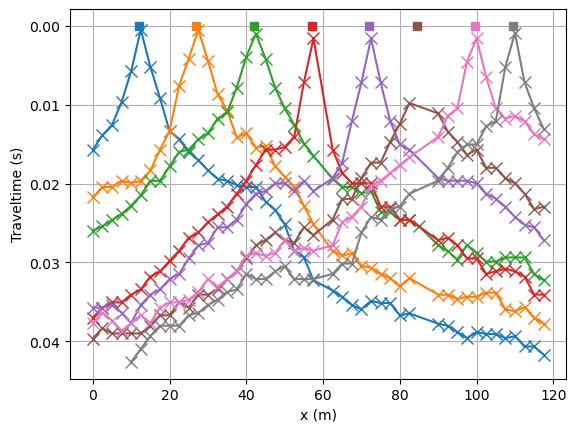

In [10]:
fig, ax = plt.subplots()
lines = tt.drawFirstPicks(ax, data)

array([<AxesSubplot:>, <AxesSubplot:>], dtype=object)

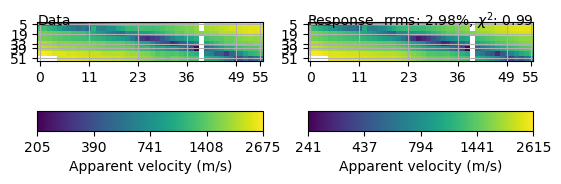

In [ ]:

mgr.showFit()


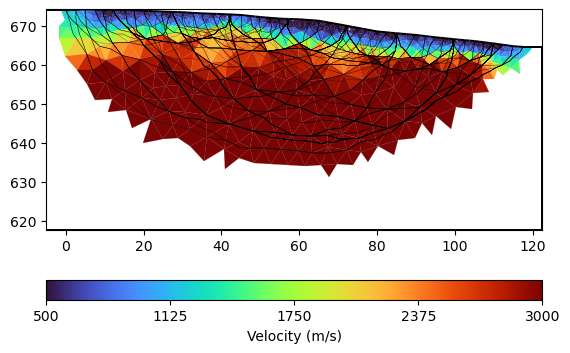

In [22]:
ax, cbar = mgr.showResult(logScale=False, cMin=500, cMax=3000, cMap="turbo",
                          coverage=mgr.standardizedCoverage())
rays = mgr.drawRayPaths(ax=ax, color="k", lw=0.3, alpha=0.5)


In [24]:
# --- Export the model (cells) ---
mesh = mgr.paraDomain                         # inversion mesh
slowness = np.asarray(mgr.model)              # one value per cell [s/m]
velocity = 1.0 / np.maximum(slowness, 1e-9)   # [m/s]
try:
    coverage = np.asarray(mgr.standardizedCoverage())
except Exception:
    coverage = None

# cell centers in PyGIMLi 2-D: x = along-profile, y = elevation (up)
cc = mesh.cellCenters()
x = np.asarray(pg.x(cc), dtype=float)
z = np.asarray(pg.y(cc), dtype=float)

# 1) CSV export (easy to inspect/import elsewhere)
cols = [x, z, velocity, slowness]
hdr  = "x_chainage(m), z_elevation(m), velocity(m/s), slowness(s/m)"
if coverage is not None:
    cols.append(coverage)
    hdr += ", coverage"

arr = np.column_stack(cols)
np.savetxt("tt_model_cells_profile.csv", arr, delimiter=",", header=hdr, comments="", fmt="%.6f")
print("Wrote: tt_model_cells_profile.csv")

Wrote: tt_model_cells_profile.csv
